# Data Pre-Processing for FoodGenie Dataset


dataset link - https://www.kaggle.com/datasets/ashishjangra27/swiggy-restaurants-dataset

In [71]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ashishjangra27/swiggy-restaurants-dataset/data.json
/kaggle/input/datasets/ashishjangra27/swiggy-restaurants-dataset/swiggy.csv


# 1. Flattening the Json file


We got a huge junk of data 


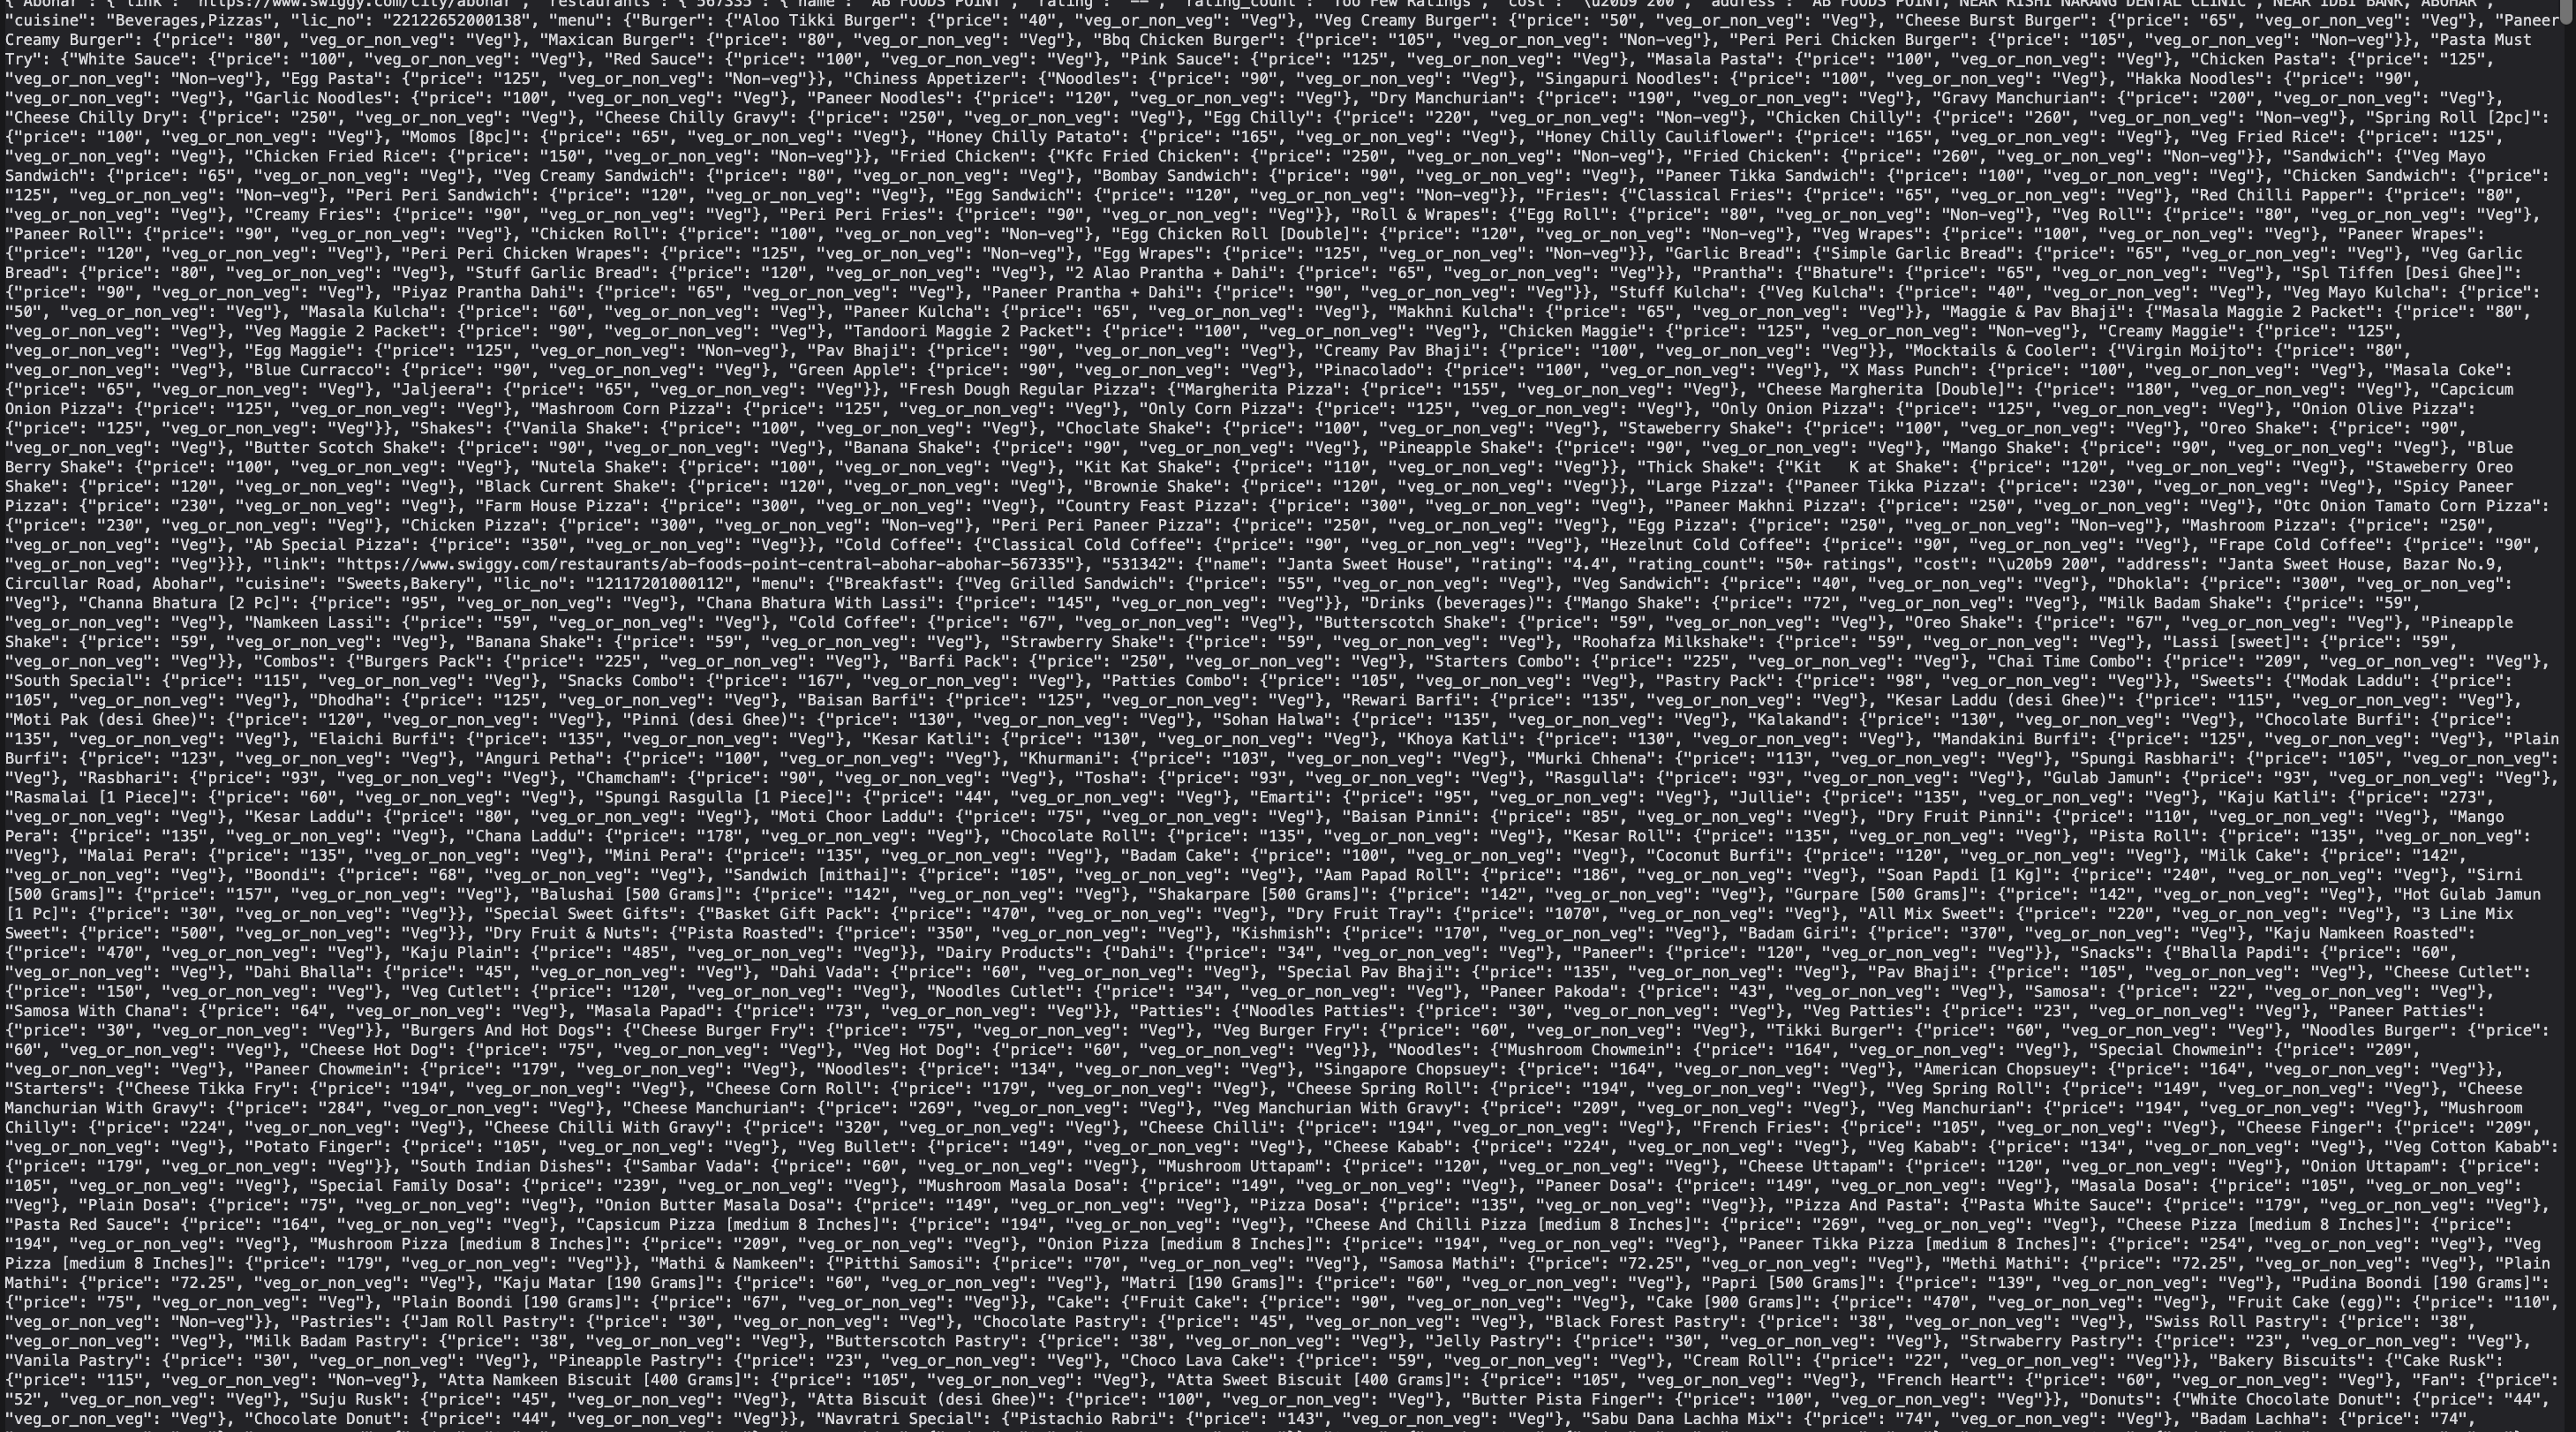


Lets make the file flatten so that the data will be suitable for ML models 




In [27]:
import json
import pandas as pd
import re

INPUT_FILE = "/kaggle/input/datasets/ashishjangra27/swiggy-restaurants-dataset/data.json"
OUTPUT_FILE = "flattened_foodgenie.parquet"

rows = []

with open(INPUT_FILE) as f:
    data = json.load(f)

for city, city_data in data.items():

    restaurants = city_data.get("restaurants", {})

    for rest_id, rest_data in restaurants.items():

        restaurant_name = rest_data.get("name")

        # ---------------- RATING ---------------- #

        rating_raw = rest_data.get("rating")
        rating_num = pd.to_numeric(rating_raw, errors="coerce")

        rating_count_raw = rest_data.get("rating_count")

        rating_count_num = None
        if rating_count_raw:
            match = re.search(r"\d+", rating_count_raw)
            if match:
                rating_count_num = int(match.group())

        # ---------------- COST ---------------- #

        cost_raw = rest_data.get("cost")

        cost_num = None
        if cost_raw:
            cost_clean = str(cost_raw).replace("₹", "").strip()
            try:
                cost_num = float(cost_clean)
            except:
                cost_num = None

        # ---------------- OTHER INFO ---------------- #

        cuisine = rest_data.get("cuisine")
        address = rest_data.get("address")

        menu = rest_data.get("menu", {})

        # ---------------- MENU LOOP ---------------- #

        for category, dishes in menu.items():

            for dish_name, dish_details in dishes.items():

                price = dish_details.get("price", "0")

                price = str(price).replace("₹", "").strip()

                try:
                    price = float(price)
                except:
                    price = 0

                veg_type = dish_details.get("veg_or_non_veg", "Unknown")

                rows.append({
                    "city": city,
                    "restaurant_id": rest_id,
                    "restaurant_name": restaurant_name,
                    "category": category,
                    "dish_name": dish_name,
                    "price": price,
                    "veg_or_non_veg": veg_type,

                    "rating_raw": rating_raw,
                    "rating_num": rating_num,

                    "rating_count_raw": rating_count_raw,
                    "rating_count_num": rating_count_num,

                    "cost_raw": cost_raw,
                    "cost_num": cost_num,

                    "cuisine": cuisine,
                    "address": address
                })

# ---------------- CREATE DATAFRAME ---------------- #

# df = pd.DataFrame(rows)

# ---------------- SAVE PARQUET ---------------- #

# df.to_parquet(OUTPUT_FILE, index=False)

print("Flattening completed")
print("Total rows:", len(df))
print("Columns:", df.columns.tolist())

Flattening complete ✅
Total rows: 4611735
Columns: ['city', 'restaurant_id', 'restaurant_name', 'category', 'dish_name', 'price', 'veg_or_non_veg', 'rating_raw', 'rating_num', 'rating_count_raw', 'rating_count_num', 'cost_raw', 'cost_num', 'cuisine', 'address']


# 2.Basic DataFrame information gathering

In [83]:
df.shape

(4611735, 16)

In [75]:
df.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4611735 entries, 0 to 4611734
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   city              object 
 1   restaurant_id     object 
 2   restaurant_name   object 
 3   category          object 
 4   dish_name         object 
 5   price             float64
 6   veg_or_non_veg    object 
 7   rating_raw        object 
 8   rating_num        float64
 9   rating_count_raw  object 
 10  rating_count_num  float64
 11  cost_raw          object 
 12  cost_num          float64
 13  cuisine           object 
 14  address           object 
 15  popularity_score  float64
dtypes: float64(5), object(11)
memory usage: 563.0+ MB


In [76]:
df.describe()

,price,rating_num,rating_count_num,cost_num,popularity_score
count,4.611735e+06,2.802816e+06,2.802816e+06,4.608958e+06,2.802816e+06
mean,2.059269e+02,3.810812e+00,8.796511e+01,2.902068e+02,1.485092e+01
std,1.755090e+02,4.282209e-01,1.203255e+02,1.349281e+03,4.906931e+00
min,0.000000e+00,1.200000e+00,1.000000e+00,1.000000e+00,1.594239e+00
25%,1.000000e+02,3.600000e+00,2.000000e+01,2.000000e+02,1.156919e+01
50%,1.700000e+02,3.900000e+00,5.000000e+01,2.500000e+02,1.522990e+01
75%,2.590000e+02,4.100000e+00,1.000000e+02,3.000000e+02,1.799897e+01
max,1.800000e+04,5.000000e+00,5.000000e+02,3.003500e+05,3.046137e+01


In [77]:
df.columns.tolist()

['city',
 'restaurant_id',
 'restaurant_name',
 'category',
 'dish_name',
 'price',
 'veg_or_non_veg',
 'rating_raw',
 'rating_num',
 'rating_count_raw',
 'rating_count_num',
 'cost_raw',
 'cost_num',
 'cuisine',
 'address',
 'popularity_score']

In [79]:
df[df["restaurant_name"] == "shere punjab veg"]
df[df["restaurant_name"] == "wah ji waah veg and non veg corner"]

,city,restaurant_id,restaurant_name,category,dish_name,price,veg_or_non_veg,rating_raw,rating_num,rating_count_raw,rating_count_num,cost_raw,cost_num,cuisine,address,popularity_score
1376,Abohar,158195,wah ji waah veg and non veg corner,All Day Breakfast,Omelette (2 Eggs Butter),60.0,Non-veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
1377,Abohar,158195,wah ji waah veg and non veg corner,All Day Breakfast,Half Fry Egg (2 Eggs Butter),60.0,Non-veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
1378,Abohar,158195,wah ji waah veg and non veg corner,All Day Breakfast,Egg Bhurji (3 Eggs Butter),80.0,Non-veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
1379,Abohar,158195,wah ji waah veg and non veg corner,Mutton & Biryani,Chicken Biryani,239.0,Non-veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
1380,Abohar,158195,wah ji waah veg and non veg corner,Mutton & Biryani,Veg Cheese Biryani,200.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1444,Abohar,158195,wah ji waah veg and non veg corner,Tandoori Bread,Butter Chapati,8.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
1445,Abohar,158195,wah ji waah veg and non veg corner,Tandoori Bread,Plain Naan,25.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
1446,Abohar,158195,wah ji waah veg and non veg corner,Tandoori Bread,Laccha Paratha,31.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN
1447,Abohar,158195,wah ji waah veg and non veg corner,Tandoori Bread,Plain Paratha,20.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"North Indian,Chinese","wah ji waah veg and non veg corner, Hanuman ga...",NaN


## 3. Null handling and other duplicated removing (data cleaning )

In [84]:
dfProcessing = pd.read_parquet('flattened_foodgenie.parquet')
dfProcessing.shape

(4611735, 15)

In [85]:
dfProcessing = dfProcessing.drop_duplicates()
dfProcessing.shape

(4611735, 15)

In [52]:
dfProcessing.isnull().sum()

city                      0
restaurant_id             0
restaurant_name           0
category                  0
dish_name                 0
price                     0
veg_or_non_veg            0
rating_raw                0
rating_num          1808919
rating_count_raw          0
rating_count_num    1808919
cost_raw                  0
cost_num               2777
cuisine                   0
address                   0
dtype: int64

In [53]:
dfProcessing["rating_num"] = dfProcessing["rating_num"].fillna(0)
dfProcessing["rating_count_num"] = dfProcessing["rating_count_num"].fillna(0)
dfProcessing["cost_num"] = dfProcessing["cost_num"].fillna(df["cost_num"].median())

In [54]:
dfProcessing.isnull().sum()

city                0
restaurant_id       0
restaurant_name     0
category            0
dish_name           0
price               0
veg_or_non_veg      0
rating_raw          0
rating_num          0
rating_count_raw    0
rating_count_num    0
cost_raw            0
cost_num            0
cuisine             0
address             0
dtype: int64

In [55]:
dfProcessing.columns

Index(['city', 'restaurant_id', 'restaurant_name', 'category', 'dish_name',
       'price', 'veg_or_non_veg', 'rating_raw', 'rating_num',
       'rating_count_raw', 'rating_count_num', 'cost_raw', 'cost_num',
       'cuisine', 'address'],
      dtype='object')

In [57]:
dfProcessing["restaurant_name"] = dfProcessing["restaurant_name"].str.strip()
dfProcessing["dish_name"] = dfProcessing["dish_name"].str.strip()
dfProcessing["category"] = dfProcessing["category"].str.strip()
dfProcessing["cuisine"] = dfProcessing["cuisine"].str.lower()
dfProcessing["city"] = dfProcessing["city"].str.lower()

In [59]:
dfProcessing.veg_or_non_veg.unique()

array(['Veg', 'Non-veg'], dtype=object)

In [61]:
#adding popularity score in order to equate the rating stars with differt rating count
dfProcessing["popularity_score"] = (
    dfProcessing["rating_num"] * np.log1p(dfProcessing["rating_count_num"])
)

In [65]:
dfProcessing.columns.unique

<bound method Index.unique of Index(['city', 'restaurant_id', 'restaurant_name', 'category', 'dish_name',
       'price', 'veg_or_non_veg', 'rating_raw', 'rating_num',
       'rating_count_raw', 'rating_count_num', 'cost_raw', 'cost_num',
       'cuisine', 'address', 'popularity_score', 'price_bucket'],
      dtype='object')>

In [86]:
#added a feature engineering to make more sense
dfProcessing["price_bucket"] = pd.cut(
    dfProcessing["price"],
    bins=[0, 200,400, np.inf],
    labels=["cheap", "mid","luxury"]
)

In [87]:
dfProcessing.head()

,city,restaurant_id,restaurant_name,category,dish_name,price,veg_or_non_veg,rating_raw,rating_num,rating_count_raw,rating_count_num,cost_raw,cost_num,cuisine,address,price_bucket
0,Abohar,567335,AB FOODS POINT,Burger,Aloo Tikki Burger,40.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",cheap
1,Abohar,567335,AB FOODS POINT,Burger,Veg Creamy Burger,50.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",cheap
2,Abohar,567335,AB FOODS POINT,Burger,Cheese Burst Burger,65.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",cheap
3,Abohar,567335,AB FOODS POINT,Burger,Paneer Creamy Burger,80.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",cheap
4,Abohar,567335,AB FOODS POINT,Burger,Maxican Burger,80.0,Veg,--,NaN,Too Few Ratings,NaN,₹ 200,200.0,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",cheap


In [70]:
# dfProcessing.to_parquet('DataPreprocessed_FoodGenie_DatasetF')